<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/16_selecting-the-best-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [3]:
set.seed(15)
n <- 100
X <- rnorm(n)
epsilon <- rnorm(n)

beta0 <- 3
beta1 <- 2
beta2 <- -1
beta3 <- 0.5

Y <- beta0 + beta1*X + beta2*X^2 + beta3*X^3 + epsilon

b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [6]:
install.packages("leaps")
library(leaps)

data <- data.frame(Y = Y)
for (i in 1:10) {
  data[[paste0("X", i)]] <- X^i
}

regfit.full <- regsubsets(Y ~ ., data = data, nvmax = 10)
reg.summary <- summary(regfit.full)
reg.summary


The downloaded binary packages are in
	/var/folders/98/fcbf3bz156j770hhtccd780w0000gq/T//Rtmp9q0arm/downloaded_packages


Subset selection object
Call: regsubsets.formula(Y ~ ., data = data, nvmax = 10)
10 Variables  (and intercept)
    Forced in Forced out
X1      FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          X1  X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" " " " " "*" " " " " " " " " " " " "
3  ( 1 )  "*" " " "*" "*" " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " "
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " "
6  ( 1 )  "*" " " "*" " " "*" "*" " " "*" " " "*"
7  ( 1 )  "*" "*" "*" "*" " " "*" " " "*" " " "*"
8  ( 1 )  "*" "*" "*" "*" "*" "*" " " "*" " " "*"
9  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*" "*" "*" "*" "*"

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Which is the best model? Report the coefficients of the best model.

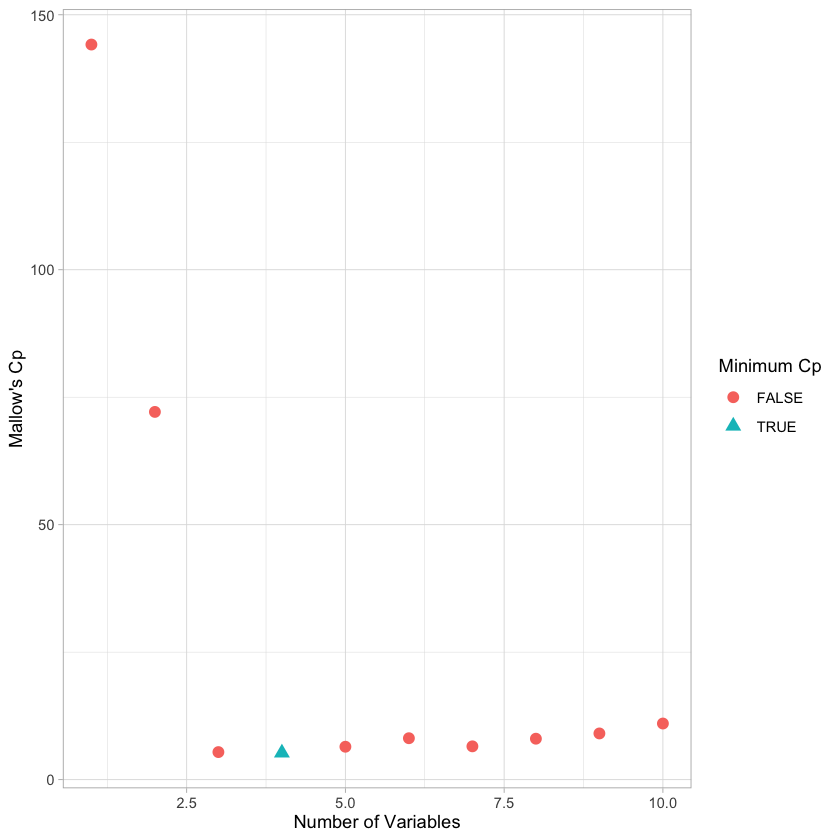

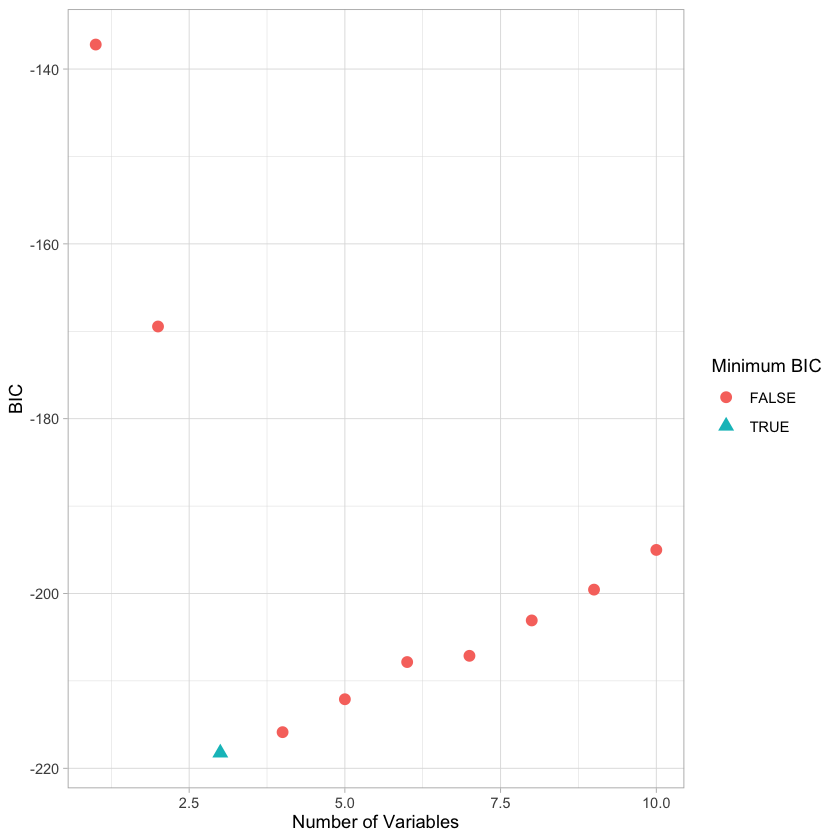

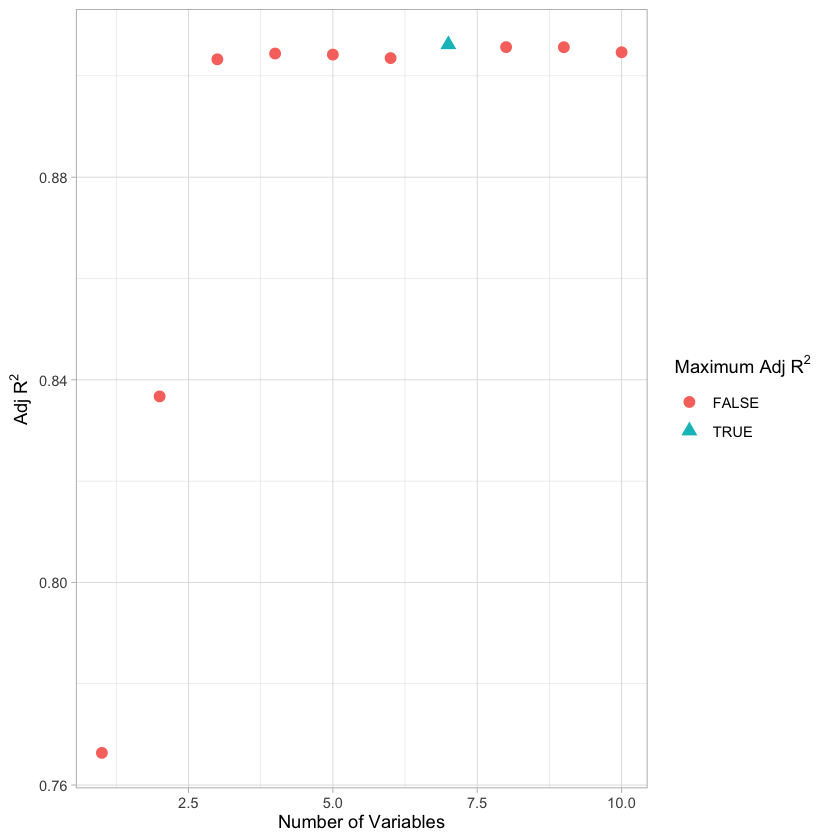

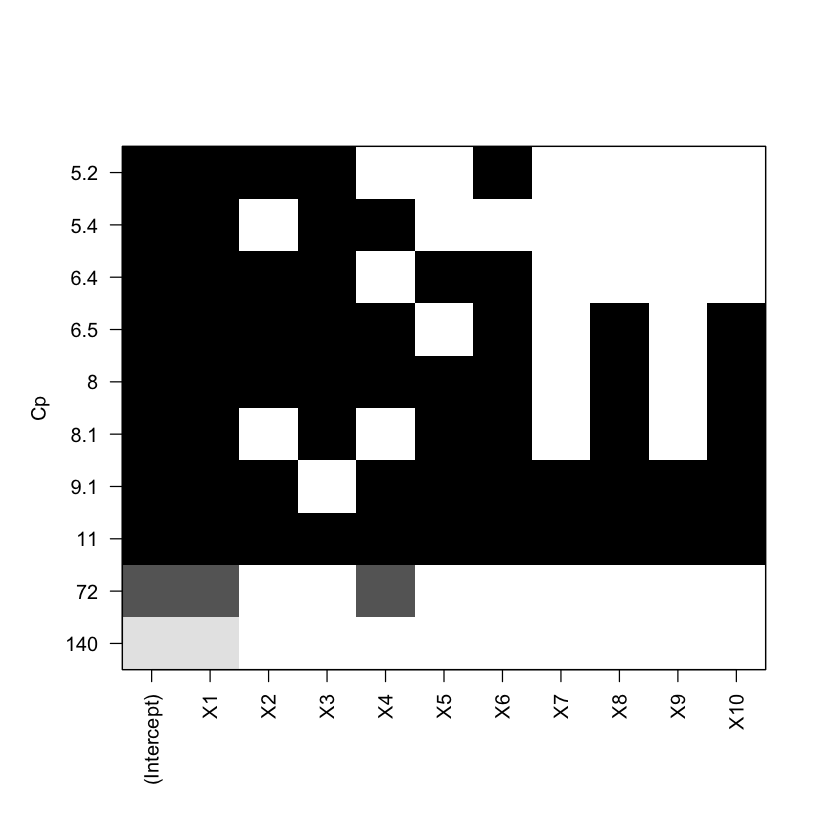

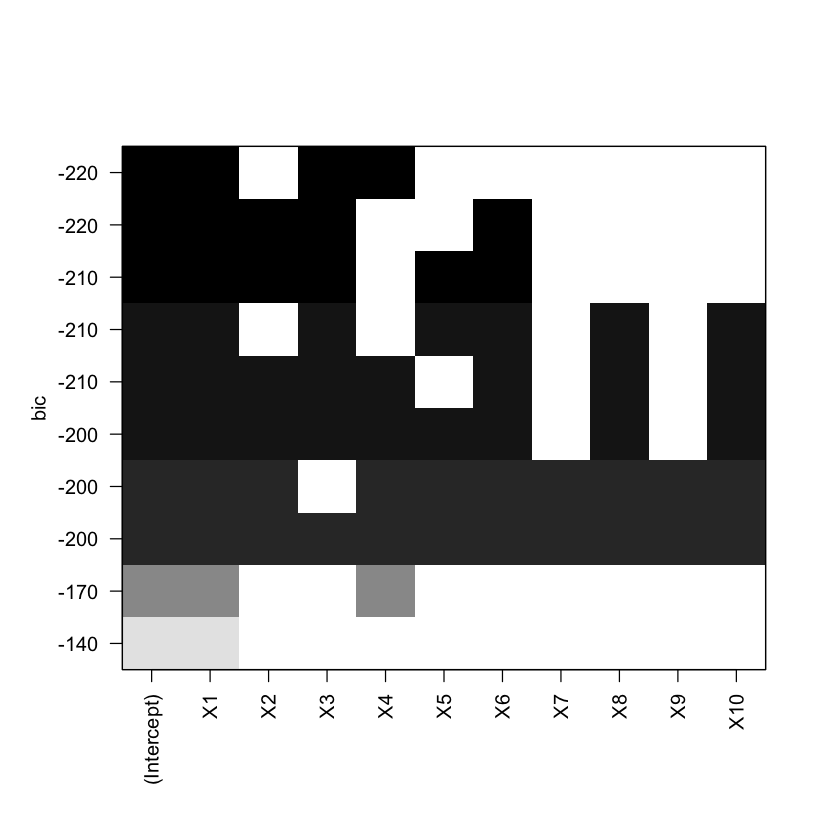

[1] 4

[1] 3

[1] 7

(Intercept)          X1          X3          X4 
  2.3808542   2.0090539   0.4985483  -0.1857347

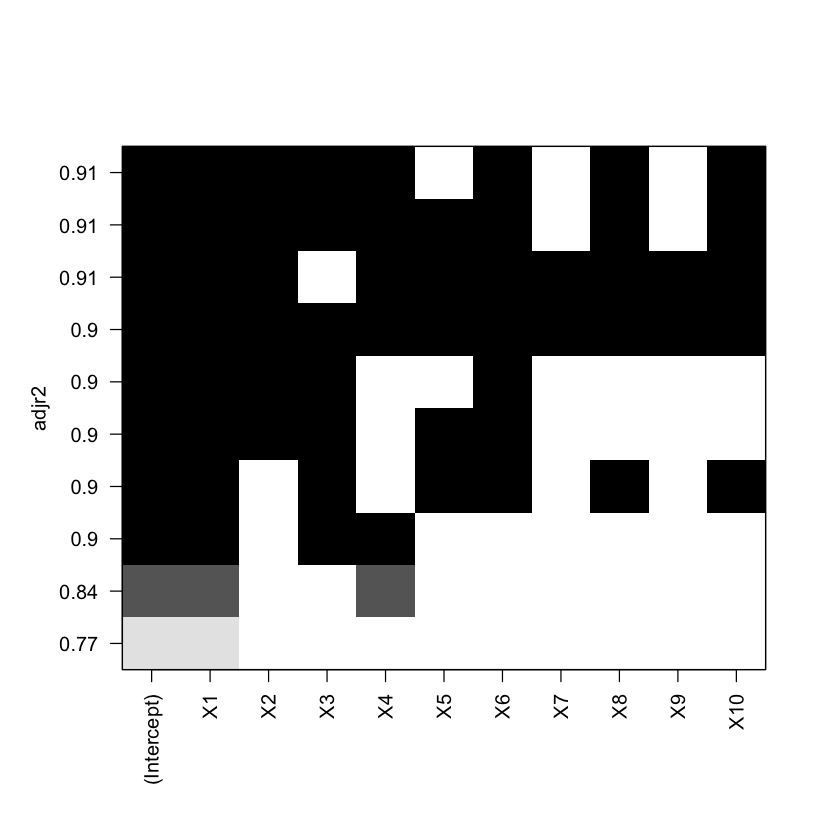

In [10]:
library(ggplot2)

numvar = 1:length(reg.summary$rss)
allfalse = rep(FALSE, length(reg.summary$rss))

# Mallow's Cp
cp.df <- data.frame(numvar = numvar, cp <- reg.summary$cp, mincp <- allfalse)
cp.df$mincp[which.min(reg.summary$cp)] <- TRUE
ggplot(cp.df, aes(x = numvar, y = cp, shape = mincp, col = mincp)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = "Mallow's Cp", color = "Minimum Cp", shape = "Minimum Cp")

# BIC
bic.df <- data.frame(numvar = numvar, bic <- reg.summary$bic, minbic <- allfalse)
bic.df$minbic[which.min(reg.summary$bic)] <- TRUE
ggplot(bic.df, aes(x = numvar, y = bic, shape = minbic, col = minbic)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = "BIC", color = "Minimum BIC", shape = "Minimum BIC")

# Adjusted R^2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- reg.summary$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(reg.summary$adjr2)] <- TRUE
ggplot(adjr2.df, aes(x = numvar, y = adjr2, shape = maxadjr2, col = maxadjr2)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color = 'Maximum Adj'~R^2, shape = 'Maximum Adj'~R^2)

# Built-in regsubsets plots
plot(regfit.full, scale = "Cp")
plot(regfit.full, scale = "bic")
plot(regfit.full, scale = "adjr2")

# Identify best model size by each criterion
which.min(reg.summary$cp)
which.min(reg.summary$bic)
which.max(reg.summary$adjr2)

# Coefficients of the best model
coef(regfit.full, which.min(reg.summary$bic))

> According to the three criteria, the best model sizes are: Mallow's Co (4 variables), BIC (3 variables), Adjusted R-square (7 variables). So from here, the best model is the 3-variable model selected by BIC, as BIC applies the strongest penalty for model complexity and is more resistant to overfitting. The Cp model with 4 variables is slightly overfit, and the Adjusted R-square model with 7 variables includes many unnecessary higher-order terms.
>
> The coefficients of the best (BIC) model are:
>
> Intercept = 2.3809
>
> X1 = 2.0091
>
> X3 = 0.4985
>
> X4 = -0.1857

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to determine the best model. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ ., data = data, nvmax = 10, method = "forward")
10 Variables  (and intercept)
    Forced in Forced out
X1      FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: forward
          X1  X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" " " " " "*" " " " " " " " " " " " "
3  ( 1 )  "*" " " "*" "*" " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" "*" " " " " " " " " " " " "
5  ( 1 )  "*" "*" "*" "*" " " " " " " " " "*" " "
6  ( 1 )  "*" "*" "*" "*" " " "*" " " " " "*" " "
7  ( 1 )  "*" "*" "*" "*" "*" "*" " " " " "*" " "
8  ( 1 )  "*" "*" "*" "*" "*" "*" "*" " " "*" " "
9  ( 1 )  "*" "*" "*" "*" "*" "*" "*" "*" "*" " "
10  ( 1 ) "*" "*" "*" "*" "*" "*"

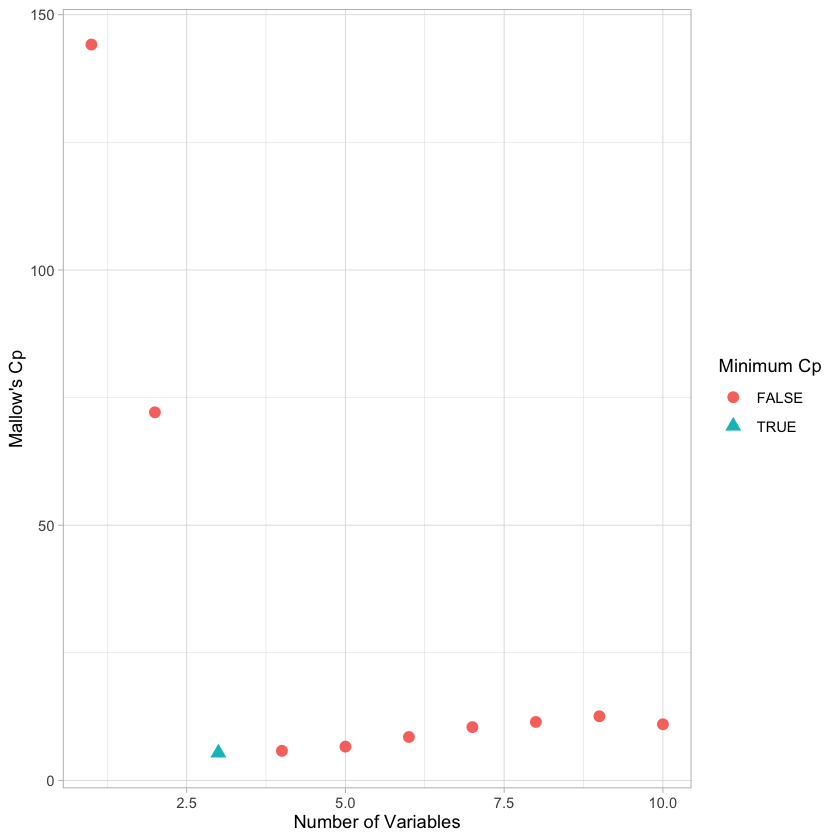

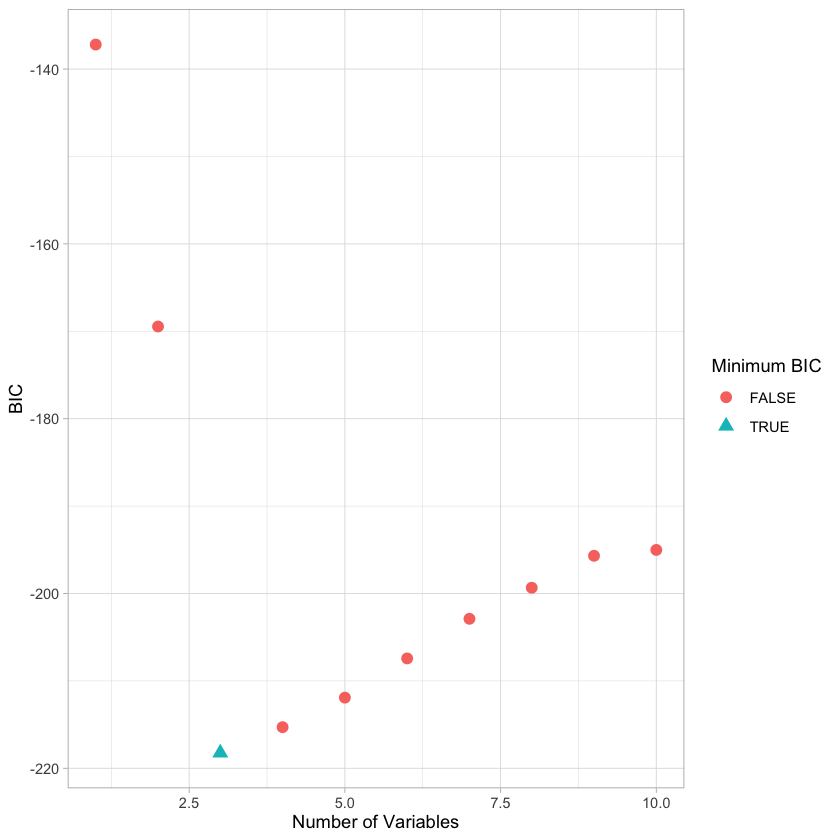

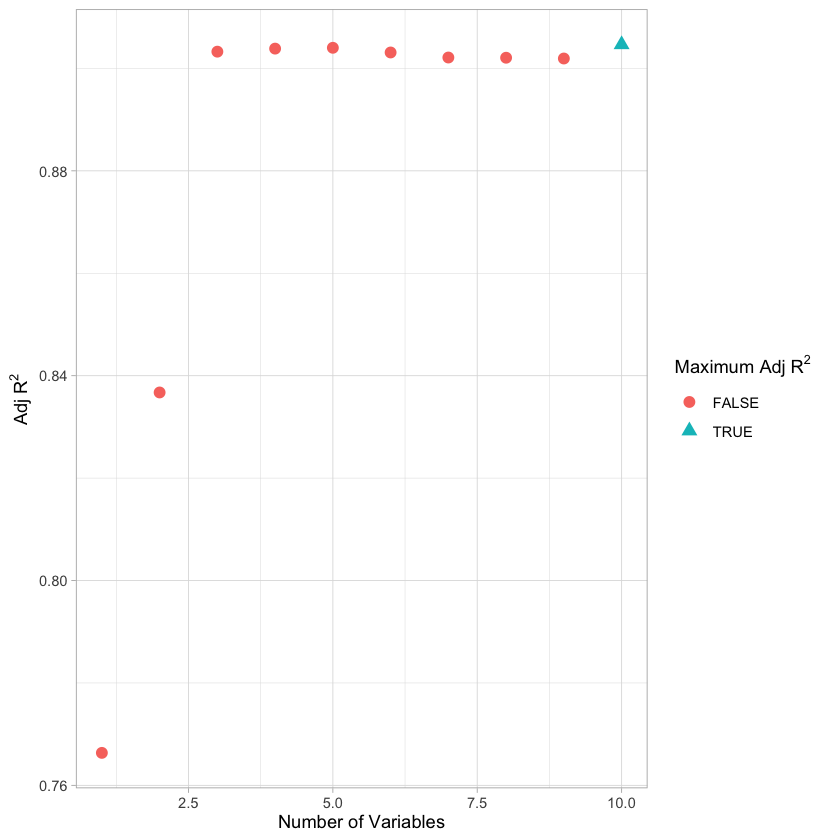

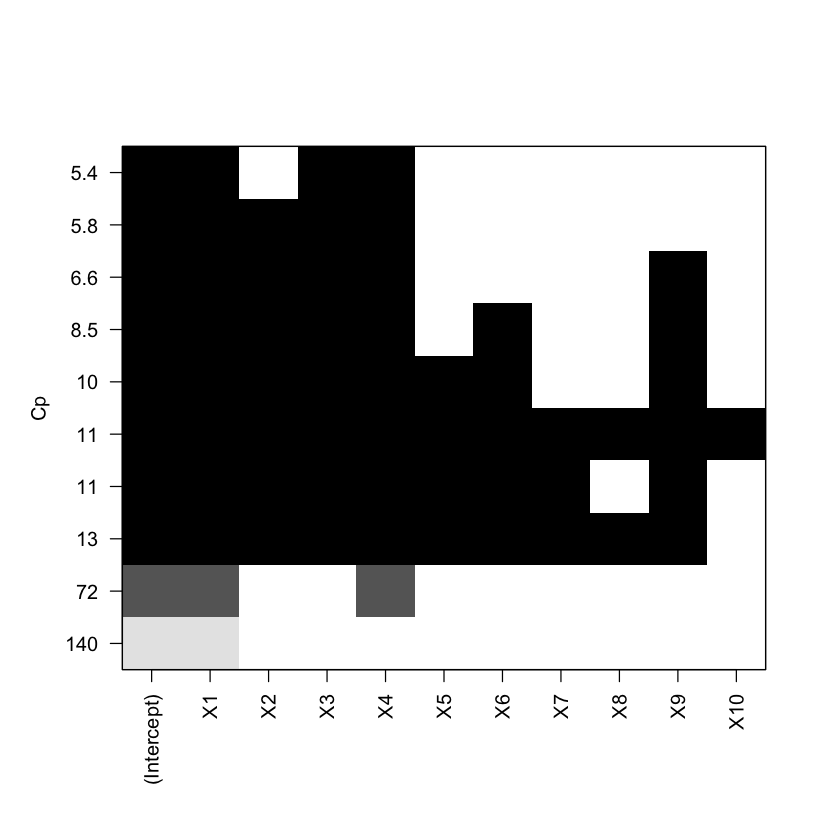

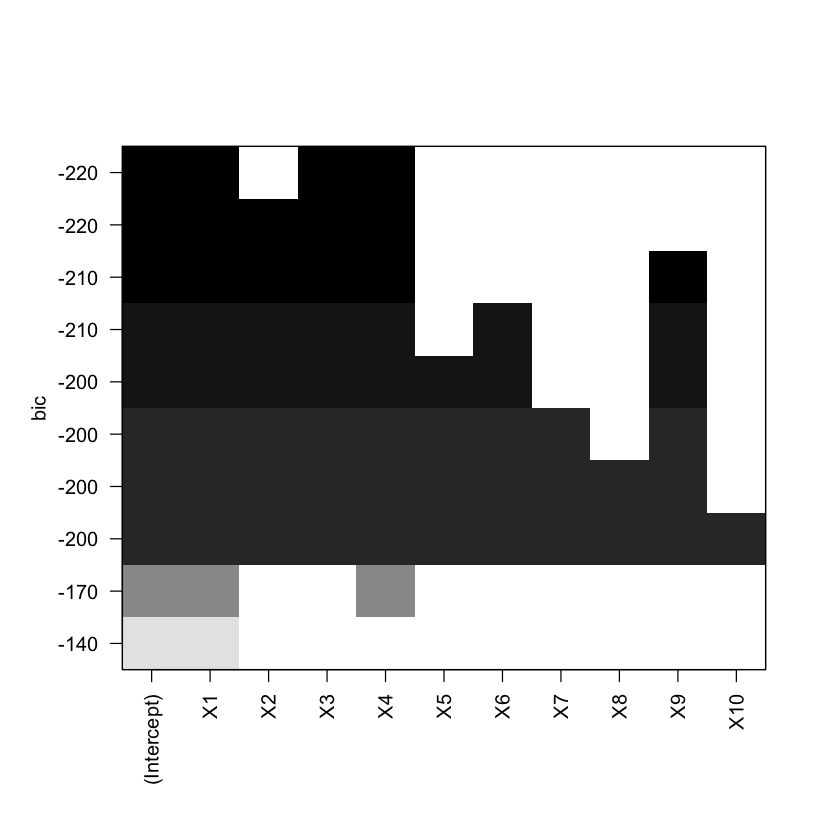

[1] 3

[1] 3

[1] 10

(Intercept)          X1          X3          X4 
  2.3808542   2.0090539   0.4985483  -0.1857347

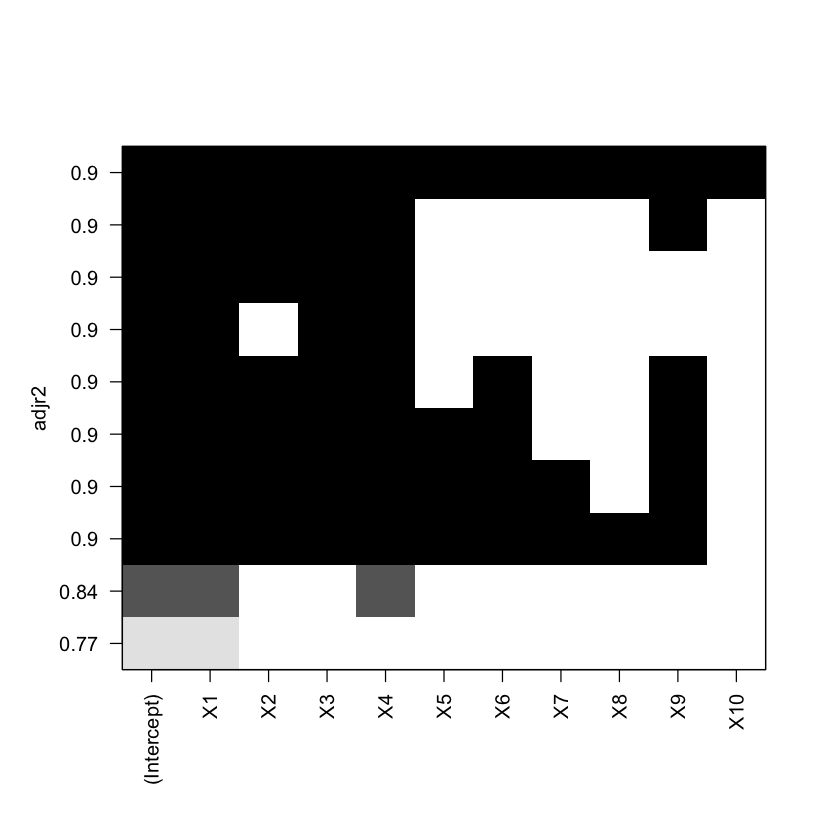

In [11]:
regfit.fwd <- regsubsets(Y ~ ., data = data, nvmax = 10, method = "forward")
fwd.summary <- summary(regfit.fwd)
fwd.summary

numvar = 1:length(fwd.summary$rss)
allfalse = rep(FALSE, length(fwd.summary$rss))

# Mallow's Cp
cp.df <- data.frame(numvar = numvar, cp <- fwd.summary$cp, mincp <- allfalse)
cp.df$mincp[which.min(fwd.summary$cp)] <- TRUE
ggplot(cp.df, aes(x = numvar, y = cp, shape = mincp, col = mincp)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = "Mallow's Cp", color = "Minimum Cp", shape = "Minimum Cp")

# BIC
bic.df <- data.frame(numvar = numvar, bic <- fwd.summary$bic, minbic <- allfalse)
bic.df$minbic[which.min(fwd.summary$bic)] <- TRUE
ggplot(bic.df, aes(x = numvar, y = bic, shape = minbic, col = minbic)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = "BIC", color = "Minimum BIC", shape = "Minimum BIC")

# Adjusted R^2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- fwd.summary$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(fwd.summary$adjr2)] <- TRUE
ggplot(adjr2.df, aes(x = numvar, y = adjr2, shape = maxadjr2, col = maxadjr2)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color = 'Maximum Adj'~R^2, shape = 'Maximum Adj'~R^2)

plot(regfit.fwd, scale = "Cp")
plot(regfit.fwd, scale = "bic")
plot(regfit.fwd, scale = "adjr2")

which.min(fwd.summary$cp)
which.min(fwd.summary$bic)
which.max(fwd.summary$adjr2)

coef(regfit.fwd, which.min(fwd.summary$bic))

b) Backwards stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ ., data = data, nvmax = 10, method = "backward")
10 Variables  (and intercept)
    Forced in Forced out
X1      FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: backward
          X1  X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  "*" " " " " " " " " " " " " " " " " " "
2  ( 1 )  "*" " " " " " " " " "*" " " " " " " " "
3  ( 1 )  "*" " " " " " " "*" "*" " " " " " " " "
4  ( 1 )  "*" "*" " " " " "*" "*" " " " " " " " "
5  ( 1 )  "*" "*" " " " " "*" "*" "*" " " " " " "
6  ( 1 )  "*" "*" " " " " "*" "*" "*" "*" " " " "
7  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" " " " "
8  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" " " "*"
9  ( 1 )  "*" "*" " " "*" "*" "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "

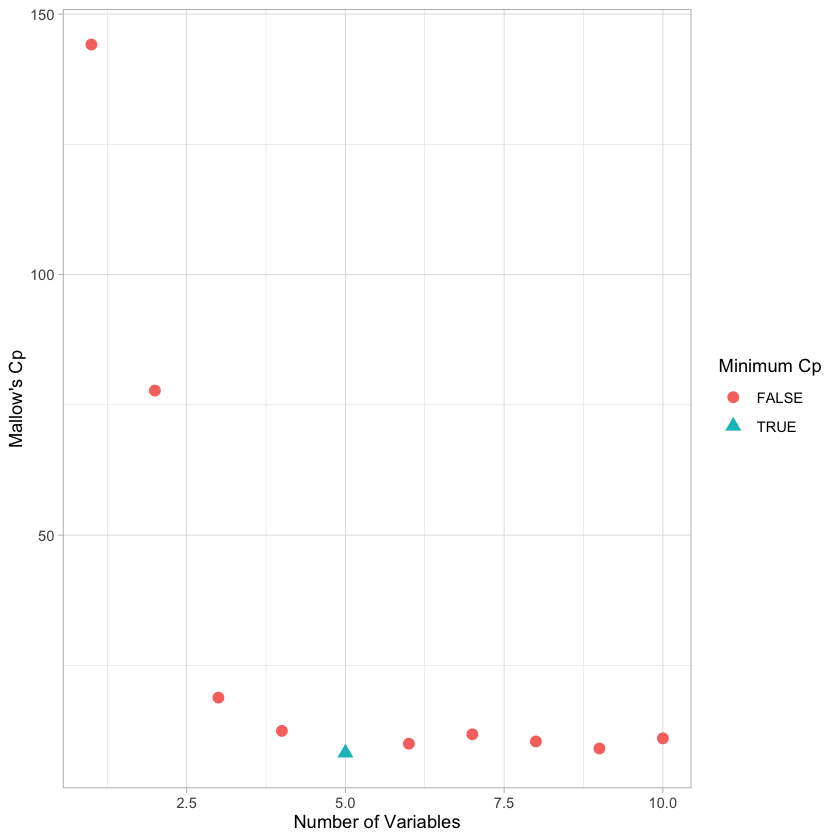

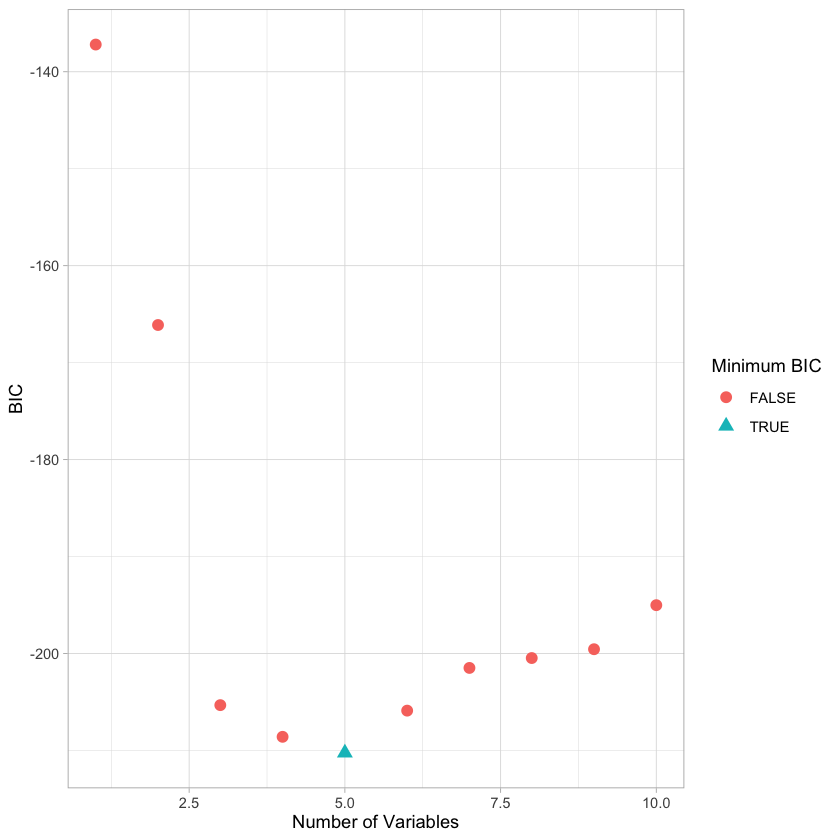

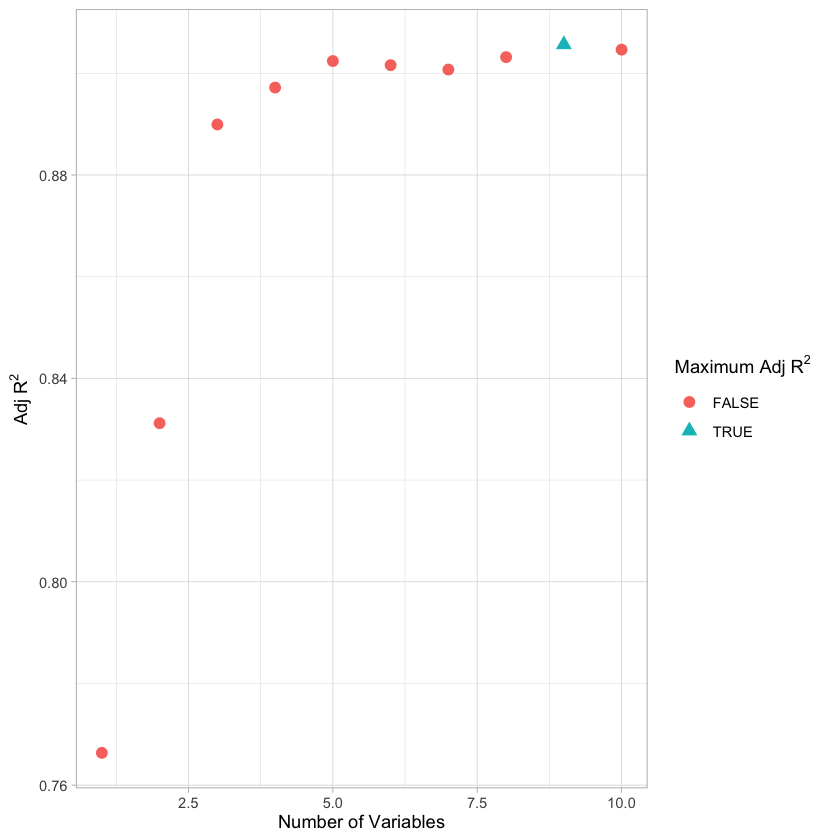

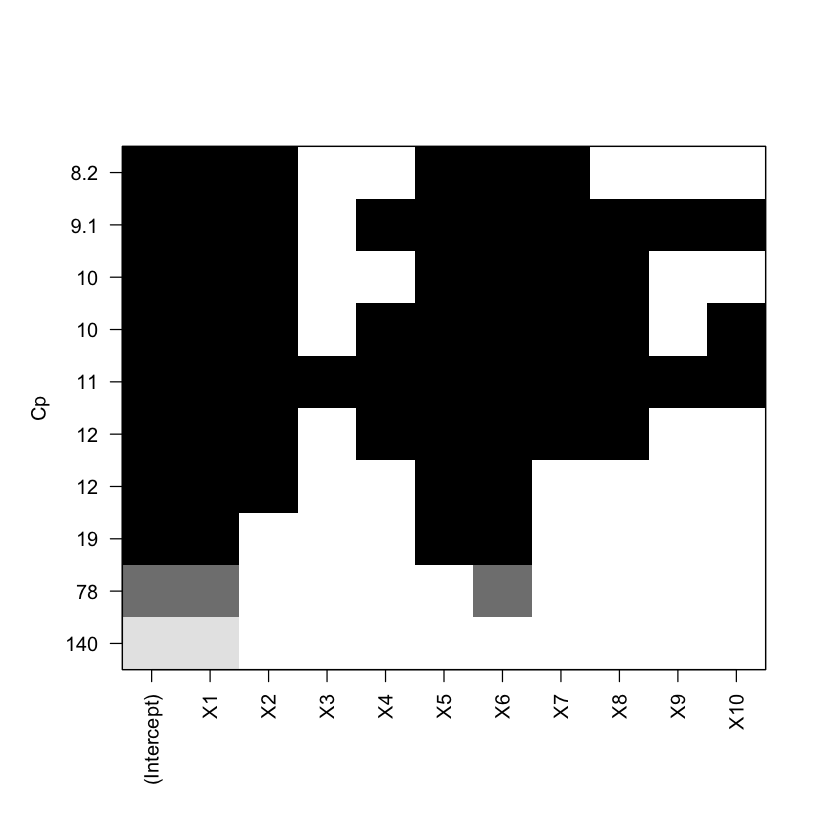

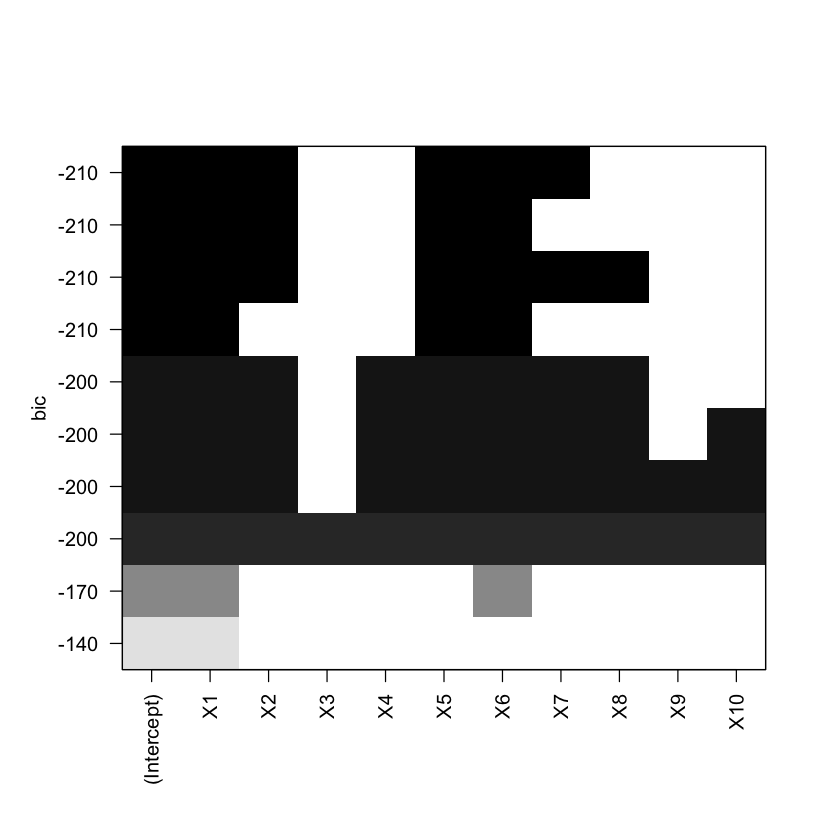

[1] 5

[1] 5

[1] 9

(Intercept)          X1          X2          X5          X6          X7 
 2.59814290  2.28224283 -0.54726429  0.22256438 -0.01604063 -0.02528877

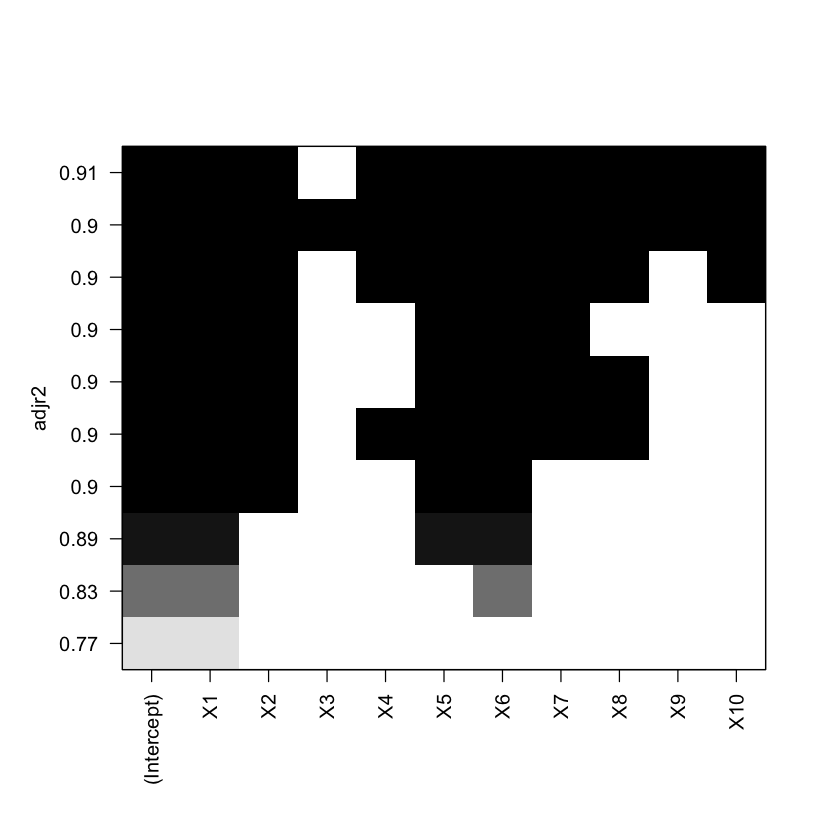

In [12]:
regfit.bwd <- regsubsets(Y ~ ., data = data, nvmax = 10, method = "backward")
bwd.summary <- summary(regfit.bwd)
bwd.summary

numvar = 1:length(bwd.summary$rss)
allfalse = rep(FALSE, length(bwd.summary$rss))

# Mallow's Cp
cp.df <- data.frame(numvar = numvar, cp <- bwd.summary$cp, mincp <- allfalse)
cp.df$mincp[which.min(bwd.summary$cp)] <- TRUE
ggplot(cp.df, aes(x = numvar, y = cp, shape = mincp, col = mincp)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = "Mallow's Cp", color = "Minimum Cp", shape = "Minimum Cp")

# BIC
bic.df <- data.frame(numvar = numvar, bic <- bwd.summary$bic, minbic <- allfalse)
bic.df$minbic[which.min(bwd.summary$bic)] <- TRUE
ggplot(bic.df, aes(x = numvar, y = bic, shape = minbic, col = minbic)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = "BIC", color = "Minimum BIC", shape = "Minimum BIC")

# Adjusted R^2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- bwd.summary$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(bwd.summary$adjr2)] <- TRUE
ggplot(adjr2.df, aes(x = numvar, y = adjr2, shape = maxadjr2, col = maxadjr2)) + 
    geom_point(size = 3) + theme_light() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color = 'Maximum Adj'~R^2, shape = 'Maximum Adj'~R^2)

plot(regfit.bwd, scale = "Cp")
plot(regfit.bwd, scale = "bic")
plot(regfit.bwd, scale = "adjr2")

which.min(bwd.summary$cp)
which.min(bwd.summary$bic)
which.max(bwd.summary$adjr2)

coef(regfit.bwd, which.min(bwd.summary$bic))

c) Compare your results from parts a and b with those of question 1.

> Best subset for question 1: Cp = 4 variables, BIC = 3 variables (X1, X3, X4), Adj R^2 = 7 variables.
> Forward stepwise: Cp = 3 variables, BIC = 3 variables (X1, X3, X4), Adj R^2 = 10 variables.
> Backward stepwise: Cp = 5 variables, BIC = 5 variables (X1, X2, X5, X6, X7), Adj R^2 = 9 variables.
>
> We can see that forward stepwise selection produced results are very similar to best subset selection in Q1. Both methods selected the same 3 variable model under BIC with identical coefficients (Intercept = 2.38; X1 = 2.01; X3 = 0.50; X4 = 0-0.19). And their Cp selections were also close.
>
> Backward stepwise selection, however, differed very much. It selected larger models across all three criteria (5, 5, and 9 variables respectively) and chose a very different set of predictors under BIC (X1, X2, X5, X6, X7) instead of X1, X3, X4. Perhaps since backward selection starts from the full model and removes variables one at a time, it may be trapped in a different path than forward selection. Since backward selection cannot revisit variables once removed, it might miss more parsimonious models that other methods found.
>
> In summary, forward stepwise and best subsets agreed closely, while backward stepwise selected larger, less parsimonious models with different predictores.

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [13]:
set.seed(15)

n <- 1000
p <- 20

X <- matrix(rnorm(n * p), nrow = n, ncol = p)
beta <- sample(c(runif(10, min = -5, max = 5), rep(0, 10)))
epsilon <- rnorm(n)

Y <- X %*% beta + epsilon

train_idx <- sample(1:n, 100)
X_train <- X[train_idx, ]
X_test <- X[-train_idx, ]
Y_train <- Y[train_idx]
Y_test <- Y[-train_idx]

train_data <- data.frame(Y = Y_train, X_train)
test_data <- data.frame(Y = Y_test, X_test)

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

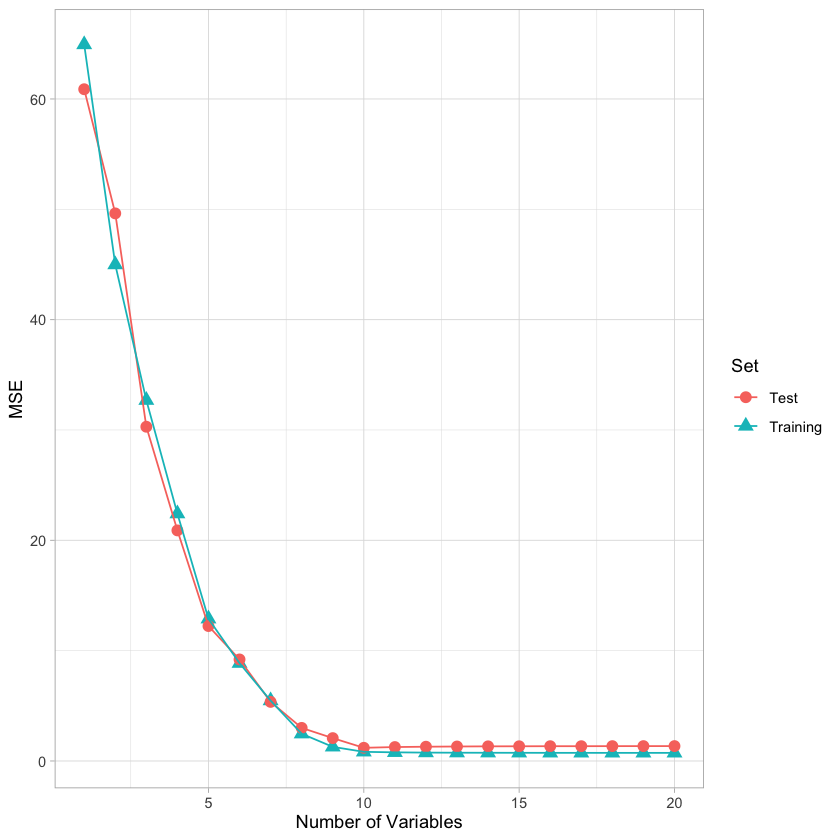

In [14]:
regfit.full <- regsubsets(Y ~ ., data = train_data, nvmax = 20)

train_mse <- rep(NA, 20)
for (i in 1:20) {
  coefi <- coef(regfit.full, id = i)
  pred_train <- cbind(1, as.matrix(train_data[, names(coefi)[-1]])) %*% coefi
  train_mse[i] <- mean((Y_train - pred_train)^2)
}

test_mse <- rep(NA, 20)
for (i in 1:20) {
  coefi <- coef(regfit.full, id = i)
  pred_test <- cbind(1, as.matrix(test_data[, names(coefi)[-1]])) %*% coefi
  test_mse[i] <- mean((Y_test - pred_test)^2)
}

mse_df <- data.frame(
  numvar = rep(1:20, 2),
  MSE = c(train_mse, test_mse),
  Type = rep(c("Training", "Test"), each = 20)
)

ggplot(mse_df, aes(x = numvar, y = MSE, col = Type, shape = Type)) + 
    geom_point(size = 3) + geom_line() + theme_light() + 
    labs(x = "Number of Variables", y = "MSE", color = "Set", shape = "Set")

c) Identify the best model according the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [15]:
best_test <- which.min(test_mse)
cat("Best model size by test MSE:", best_test, "\n")

coef(regfit.full, best_test)

cat("\nTrue beta coefficients:\n")
print(beta)

Best model size by test MSE: 10 


(Intercept)          X2          X3          X4         X12         X14 
 -0.0394260   4.8011203  -1.4139195   2.1176756   0.9745151   2.7410567 
        X15         X16         X17         X18         X19 
  4.4537663  -0.8437945  -2.8011851  -1.8272593  -4.1855297


True beta coefficients:
 [1]  0.0000000  4.7455551 -1.4354722  1.9069900  0.0000000  0.0000000
 [7]  0.0000000  0.0000000  0.0000000  0.0000000  0.0000000  0.9000783
[13]  0.0000000  2.7456203  4.5109650 -0.9327975 -2.8850834 -1.6626631
[19] -4.0305049  0.0000000


> According to the test MSE, the best model has 10 variables: X2. X3, X4, X12, X14, X15, X16, X17, X18, and X19. This matches the true model pretty well I guess. The true beta vector has 10 nonzero coefficients at positions 2, 3, 4, 12, 14, 15, 15, 16, 17, 18, and 19, which are the same variables selected by best subset selection. So the estimated coefficients are also close to the true values. The plot above also shows the expected behavior that training MSe decreases monotonically as more variables are added, while the test MSE decreases until around 10 variables and then slightly increases, so there may be overfittig when unnecessary predictors are included.

**DUE:** 5pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*